In [1]:
%pip install -q --no-warn-conflicts malariagen_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 22.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.1/216.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.

Note that authentication is required to access data through the package, please follow the instructions [here](https://malariagen.github.io/vector-data/vobs/vobs-data-access.html).

In [2]:
import malariagen_data

In [3]:
import pandas as pd
import numpy as np
import allel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook+colab"

In [ ]:
#import os
#os.environ["MGEN_SHOW_PROGRESS"] = "0"

In [5]:
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL                           : gs://vo_agam_release_master_us_central1/
Data releases available               : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache                         : None
Cohorts analysis                      : 20250815
AIM analysis                          : 20220528
Site filters analysis                 : dt_20200416
Software version                      : malariagen_data 15.5.0
Client location                       : South Carolina, United States (Google Cloud us-east1)
Data filtered to unrestricted use only: False
Data filtered to surveillance use only: False
Relevant data releases                : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.5.0/Ag3.html

## Extract haplotypes from the region of interest

In [6]:
tpp_haps = ag3.haplotypes(region="3R: 7163635 - 7165312",
                           sample_sets="3.0")

In [ ]:
tpp_haps

<xarray.Dataset> Size: 80MB
Dimensions:           (variants: 14363, alleles: 2, samples: 2784, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 57kB dask.array<chunksize=(14363,), meta=np.ndarray>
    variant_contig    (variants) uint8 14kB dask.array<chunksize=(14363,), meta=np.ndarray>
    sample_id         (samples) object 22kB dask.array<chunksize=(81,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 29kB dask.array<chunksize=(14363, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 80MB dask.array<chunksize=(14363, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu_arab

## Extract the variant positions

In [7]:
pos = allel.SortedIndex(sorted(tpp_haps["variant_position"].values))
pos.shape

(653,)

## Extract the haplotype itself

In [8]:
gt = tpp_haps["call_genotype"].values

In [ ]:
gt.shape

(653, 2784, 2)

In [ ]:
gt

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=int8)

## Reshape the genotype to a two-dimensional data

In [9]:
ht = gt.reshape(gt.shape[0], -1)

In [ ]:
ht.shape

(14363, 5568)

## Convert to a Haplotype Array

In [10]:
haps = allel.HaplotypeArray(ht)

In [ ]:
haps.shape

(653, 5568)

In [ ]:
haps

<HaplotypeArray shape=(653, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

In [ ]:
pos

0,1,2,3,4,...,648,649,650,651,652
np.int32(7163636),np.int32(7163641),np.int32(7163644),np.int32(7163645),np.int32(7163647),...,np.int32(7165291),np.int32(7165292),np.int32(7165300),np.int32(7165301),np.int32(7165309)


## Define the Transcript and the Cohort to work with

In [11]:
transcript = "AGAP008225-RA"

In [12]:
cohorts = "admin1_year"

## Call the SNPs in that transcript

In [13]:
variants = ag3.snp_allele_frequencies(transcript= transcript,
                                      cohorts= cohorts,
                                      sample_sets = '3.0',
                                      drop_invariant=False,
)
variants

Load SNP genotypes:   0%|          | 0/149 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/54 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/5034 [00:00<?, ?it/s]

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3R     7163635  G          A          NaN                       True   
                           C          NaN                       True   
                           T          NaN                       True   
       7163636  C          A          NaN                       True   
                           T          NaN                       True   
...                                                              ...   
       7165311  A          T          NaN                       True   
                           G          NaN                       True   
       7165312  T          A          NaN                      False   
                           C          NaN                      False   
                           G          NaN                      False   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3R     7163635  G          A          NaN                  True       True   
                           C          NaN                  True       True   
                           T          NaN                  True       True   
       7163636  C          A          NaN                  True       True   
                           T          NaN                  True       True   
...                                                         ...        ...   
       7165311  A          T          NaN                  True       True   
                           G          NaN                  True       True   
       7165312  T          A          NaN                  True      False   
                           C          NaN                  True      False   
                           G          NaN                  True      False   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
3R     7163635  G          A          NaN                    0.000000   
                           C          NaN                    0.000000   
                           T          NaN                    0.000000   
       7163636  C          A          NaN                    0.000000   
                           T          NaN                    0.000000   
...                                                               ...   
       7165311  A          T          NaN                    0.000000   
                           G          NaN                    0.080247   
       7165312  T          A          NaN                    0.000000   
                           C          NaN                    0.000000   
                           G          NaN                    0.000000   

                                                 frq_BF-07_gamb_2004  \
contig position ref_allele alt_allele aa_change                        
3R     7163635  G          A          NaN                        0.0   
                           C          NaN                        0.0   
                           T          NaN                        0.0   
       7163636  C          A          NaN                        0.0   
                           T          NaN                        0.0   
...                                                              ...   
       7165311  A          T          NaN                        0.0   
                           G          NaN                        0.0   
       7165312  T          A          NaN                        0.0   
                           C          NaN                        0.0   
                           G          NaN                        0.0   

                                                 frq_BF-09_colu_2012  \
contig position ref_allele alt_allele aa_change                        
3R     7163635  G          A          NaN                   0.0000

## Group such that only nsSNPs that occur at least once at a frequency of 0.05 in any cohort is extracted

In [14]:
missense_variants = variants.query("effect == 'NON_SYNONYMOUS_CODING' and max_af >= 0.05")
missense_variants

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3R     7163844  G          A          R3Q                       True   
       7163846  A          G          S4G                       True   
       7163847  G          A          S4N                       True   
       7163862  C          A          P9Q                       True   
       7163896  G          T          K20N                      True   
       7163897  C          T          P21S                      True   
       7163928  A          T          D31V                      True   
       7163937  C          T          A34V                     False   
       7163946  A          T          H37L                      True   
       7164144  C          G          A79G                      True   
       7164216  T          G          V103G                    False   
       7164218  G          A          D104N                     True   
       7164245  G          A          E113K                     True   
       7164297  G          C          G130A                    False   
       7164299  A          C          T131P                    False   
       7164300  C          T          T131I                     True   
       7164303  G          A          R132H                     True   
       7164352  G          C          M148I                     True   
       7164360  A          G          Q151R                     True   
       7164366  A          C          N153T                     True   
       7164537  C          T          A187V                     True   
       7164557  G          C          E194Q                     True   
       7164567  G          C          G197A                     True   
       7164616  C          G          I213M                     True   
       7164668  G          A          A231T                     True   
       7164705  A          C          D243A                    False   
       7164734  A          C          M253L                     True   
       7164753  G          A          R259K                     True   
       7164771  A          C          K265T                     True   
                           G          K265R                     True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3R     7163844  G          A          R3Q                  True       True   
       7163846  A          G          S4G                  True       True   
       7163847  G          A          S4N                  True       True   
       7163862  C          A          P9Q                  True       True   
       7163896  G          T          K20N                 True       True   
       7163897  C          T          P21S                 True       True   
       7163928  A          T          D31V                 True       True   
       7163937  C          T          A34V                 True      False   
       7163946  A          T          H37L                 True       True   
       7164144  C          G          A79G                 True       True   
       7164216  T          G          V103G               False      False   
       7164218  G          A          D104N                True       True   
       7164245  G          A          E113K                True       True   
       7164297  G          C          G130A               False      False   
       7164299  A          C          T131P               False      False   
       7164300  C          T          T131I                True       True   
       7164303  G          A          R132H                True       True   
       7164352  G          C          M148I                True       True   
       7164360  A          G          Q151R                True       True   
       7164366  A          C          N153T                True       True   
       7164537  C          T

## Extract the indexes

In [15]:
tpp_index = missense_variants[[]]
tpp_index


Empty DataFrame
Columns: []
Index: [(3R, 7163844, G, A, R3Q), (3R, 7163846, A, G, S4G), (3R, 7163847, G, A, S4N), (3R, 7163862, C, A, P9Q), (3R, 7163896, G, T, K20N), (3R, 7163897, C, T, P21S), (3R, 7163928, A, T, D31V), (3R, 7163937, C, T, A34V), (3R, 7163946, A, T, H37L), (3R, 7164144, C, G, A79G), (3R, 7164216, T, G, V103G), (3R, 7164218, G, A, D104N), (3R, 7164245, G, A, E113K), (3R, 7164297, G, C, G130A), (3R, 7164299, A, C, T131P), (3R, 7164300, C, T, T131I), (3R, 7164303, G, A, R132H), (3R, 7164352, G, C, M148I), (3R, 7164360, A, G, Q151R), (3R, 7164366, A, C, N153T), (3R, 7164537, C, T, A187V), (3R, 7164557, G, C, E194Q), (3R, 7164567, G, C, G197A), (3R, 7164616, C, G, I213M), (3R, 7164668, G, A, A231T), (3R, 7164705, A, C, D243A), (3R, 7164734, A, C, M253L), (3R, 7164753, G, A, R259K), (3R, 7164771, A, C, K265T), (3R, 7164771, A, G, K265R)]

## Conver the object to a dataframe

In [16]:
tpp_df = pd.DataFrame(list(tpp_index.index), columns=[
    "contig", "position", "ref_allele", "alt_allele", "aa_change"
])
tpp_df

,contig,position,ref_allele,alt_allele,aa_change
0,3R,7163844,G,A,R3Q
1,3R,7163846,A,G,S4G
2,3R,7163847,G,A,S4N
3,3R,7163862,C,A,P9Q
4,3R,7163896,G,T,K20N
5,3R,7163897,C,T,P21S
6,3R,7163928,A,T,D31V
7,3R,7163937,C,T,A34V
8,3R,7163946,A,T,H37L
9,3R,7164144,C,G,A79G


## Sort the positions of the selected variants

In [17]:
pos_selected = allel.SortedIndex(sorted(tpp_df['position']))

In [ ]:
pos_selected

0,1,2,3,4,...,25,26,27,28,29
np.int64(7163844),np.int64(7163846),np.int64(7163847),np.int64(7163862),np.int64(7163896),...,np.int64(7164705),np.int64(7164734),np.int64(7164753),np.int64(7164771),np.int64(7164771)


## Use that file to locate the keys of the positions in the main position file. Set the strict parameter to ensure that only the present positions are called, else it will create an error.

In [18]:
loc_selected = pos.locate_keys(pos_selected, strict= False)
loc_selected

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
        True, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False,

## Use said file to select the haplotypes corresponding to the selected positions

In [19]:
haps_selected = haps[loc_selected]
haps_selected

<HaplotypeArray shape=(15, 5568) dtype=int8>
0 1 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

## Define a function that checks the position in pos_selected that are not found in pos so they can be easily removed

In [20]:
def get_missing_values(idx1, idx2):
    missing_values = []
    for i in idx1:
        if i not in idx2:
            missing_values.append(i)
    return missing_values

In [21]:
values_to_remove = get_missing_values(pos_selected, pos)

## this creates a dataframe that holds the mutations whose haplotypes are present.

In [22]:
tpp_df2 = tpp_df[~tpp_df["position"].isin(values_to_remove)]
tpp_df2.shape

(15, 5)

## this creates a dataframe to show which mutations were not present and were subsequently removed

In [ ]:
tpp_mut = tpp_df[tpp_df["position"].isin(values_to_remove)]
tpp_mut.shape

(15, 5)

In [ ]:
ac = haps_selected.count_alleles()
ac.displayall()

,0,1
0,5220,348
1,5500,68
2,5565,3
3,5556,12
4,5565,3
5,5373,195
6,4729,839
7,3395,2173
8,5475,93
9,5263,305


## Define the function to compute the Lenwontin D'

In [23]:
def lewontin_d_prime(h, i, j, a=1, b=1):
    """
    h = haplotype matrix (SNPs × haplotypes)
    i = index of SNP1
    j = index of SNP2
    a = derived allele at SNP1
    b = derived allele at SNP2
    """
    n_a = n_b = 0
    n_ab = 0
    n = 0

    for k in range(h.shape[1]):
        allele_i = h[i, k]
        allele_j = h[j, k]
        if allele_i < 0 or allele_j < 0:
            continue

        if allele_i == a:
            n_a += 1
        if allele_j == b:
            n_b += 1
        if allele_i == a and allele_j == b:
            n_ab += 1
        n += 1

    if n == 0 or n_a == 0 or n_b == 0 or n == n_a or n == n_b:
        return np.nan

    D = (n * n_ab) - (n_a * n_b)

    if D >= 0:
        Dmax = min(n_a * (n - n_b), (n - n_a) * n_b)
    else:
        Dmax = min(n_a * n_b, (n - n_a) * (n - n_b))

    return D / Dmax

## Create the pairwise matrix

In [24]:
n = haps_selected.shape[0]
ld_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dprime = lewontin_d_prime(haps_selected, i, j, 1, 1)
        ld_matrix[i, j] = dprime
        ld_matrix[j, i] = dprime

## create a new column that combines all the information in your dataframe

In [25]:
tpp_df2["label"] = (
    tpp_df2["position"].astype(str)
    + ": "
    + tpp_df2["ref_allele"].astype(str)
    + ">"
    + tpp_df2["alt_allele"].astype(str)
    + " "
    + tpp_df2["aa_change"]
)
tpp_df2

/tmp/ipython-input-2288105605.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,contig,position,ref_allele,alt_allele,aa_change,label
0,3R,7163844,G,A,R3Q,7163844: G>A R3Q
2,3R,7163847,G,A,S4N,7163847: G>A S4N
3,3R,7163862,C,A,P9Q,7163862: C>A P9Q
5,3R,7163897,C,T,P21S,7163897: C>T P21S
6,3R,7163928,A,T,D31V,7163928: A>T D31V
11,3R,7164218,G,A,D104N,7164218: G>A D104N
12,3R,7164245,G,A,E113K,7164245: G>A E113K
16,3R,7164303,G,A,R132H,7164303: G>A R132H
17,3R,7164352,G,C,M148I,7164352: G>C M148I
18,3R,7164360,A,G,Q151R,7164360: A>G Q151R


## create an array of your labels to be used

In [26]:
labels = tpp_df2["label"].to_numpy()

In [27]:
ld_df = pd.DataFrame(ld_matrix, index=labels, columns=labels)

In [28]:
ld_df.to_excel("tppld_matrix.xlsx")

## Plotting the heatmap

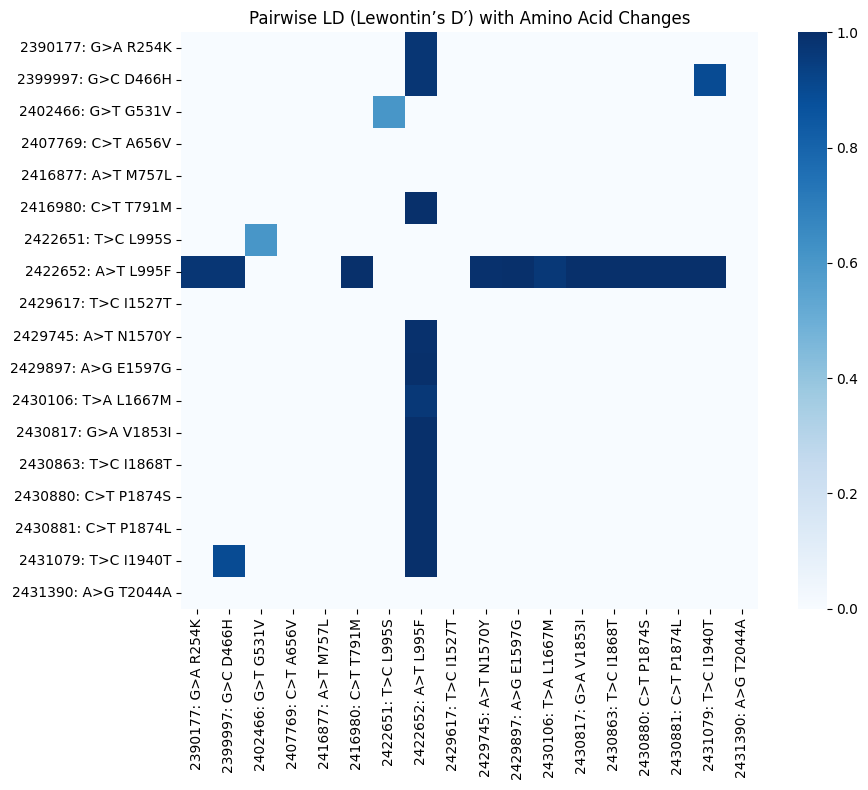

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(ld_df, cmap="Blues", vmin=0, vmax=1, square=True,
            xticklabels=True, yticklabels=True)

plt.title("Pairwise LD (Lewontin’s D′) with Amino Acid Changes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##define a function that plots your heatmap with gridspace

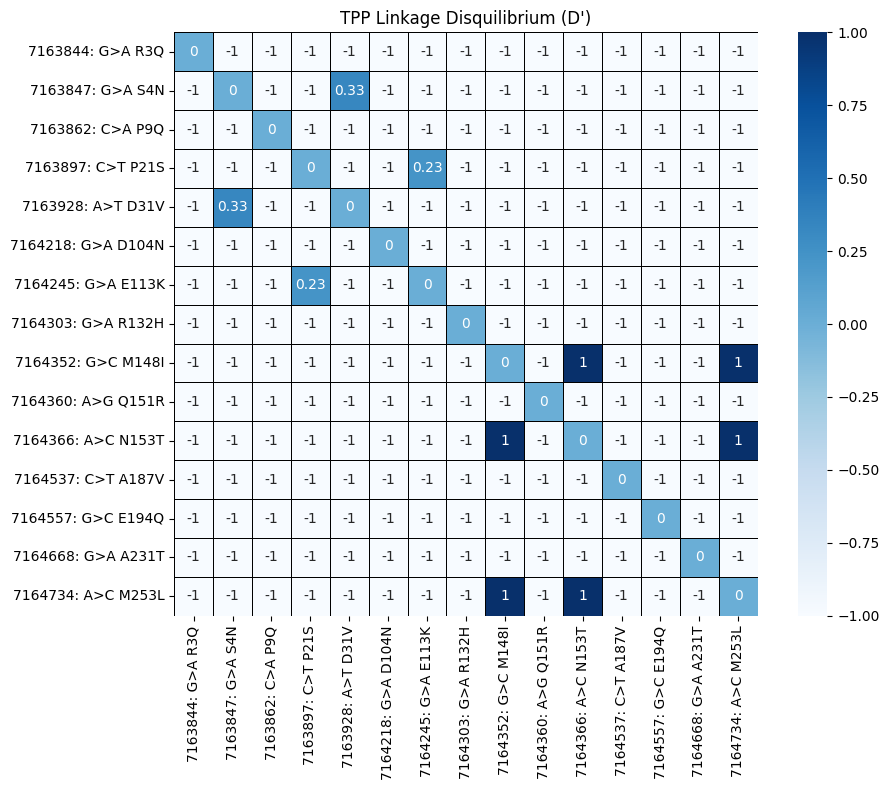

In [30]:
def plot_ld_with_gridspec(ld_df, title="TPP Linkage Disquilibrium (D')"):
    n = ld_df.shape[0]

    # -------------------------------------------
    # 1. Setup GridSpec for the plot
    # -------------------------------------------
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])

    # -------------------------------------------
    # 2. Draw the heatmap
    # -------------------------------------------
    sns.heatmap(
        ld_df,
        cmap="Blues",
        vmin=-1, vmax=1, center=0,
        annot=True,
        square=True,
        linewidths=0.5,        # visible gridlines!
        linecolor="black",     # gridline color
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    # -------------------------------------------
    # 3. Axis and title formatting
    # -------------------------------------------
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis='both', which='major')

    plt.tight_layout()
    plt.show()


# Example usage:
plot_ld_with_gridspec(ld_df)
